# LEVEL 2
# TASK 2 – Wine Quality Prediction

## Objective

Build and evaluate machine learning classification models to predict wine quality based on its physicochemical properties.

## Tech Stack

- Python
- pandas
- NumPy
- scikit-learn
- Matplotlib
- Jupyter Notebook

## Project Overview

In this project, we will inspect the wine quality dataset, prepare the target variable for classification, perform feature engineering, analyse class imbalance, split the data into training and testing sets, train and compare multiple classification models, evaluate them using precision, recall, F1-score, and ROC-AUC, and interpret the model results.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

In [2]:
columns = [
    "fixed_acidity",
    "volatile_acidity",
    "citric_acid",
    "residual_sugar",
    "chlorides",
    "free_sulfur_dioxide",
    "total_sulfur_dioxide",
    "density",
    "pH",
    "sulphates",
    "alcohol",
    "quality"
]
df = pd.read_csv(
    "winequality-red.csv",
    header=None,
    names=columns
)
df.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nQuality class distribution:")
print(df["quality"].value_counts().sort_index())

Number of rows: 1599
Number of columns: 12

Data types:
fixed_acidity           float64
volatile_acidity        float64
citric_acid             float64
residual_sugar          float64
chlorides               float64
free_sulfur_dioxide     float64
total_sulfur_dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

Missing values:
fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Quality class distribution:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


## Feature Engineering – Quality Classification

The original `quality` variable contains six observed quality scores ranging from 3 to 8. The class distribution is highly uneven, with quality scores of 5 and 6 representing most of the observations, while scores such as 3 and 8 are rare.

For this classification task, the quality score will be converted into two classes:

* **Bad:** quality < 6
* **Good:** quality >= 6

A binary classification approach was selected because it reduces the effect of the severe imbalance among the original quality scores and produces two more balanced groups for model training.

This transformation will be used as the target variable for the classification models.


In [4]:
df["quality_class"] = np.where(
    df["quality"] >= 6,
    "Good",
    "Bad"
)
print(df["quality_class"].value_counts())

quality_class
Good    855
Bad     744
Name: count, dtype: int64


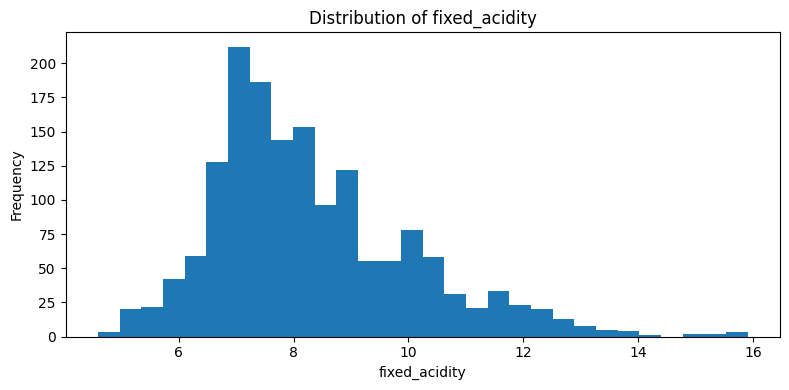

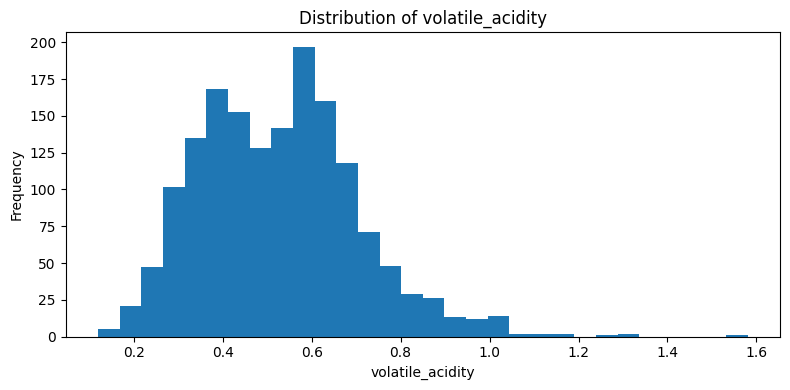

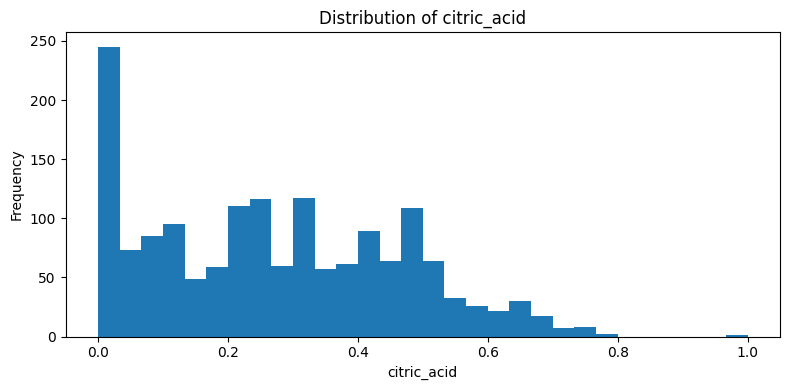

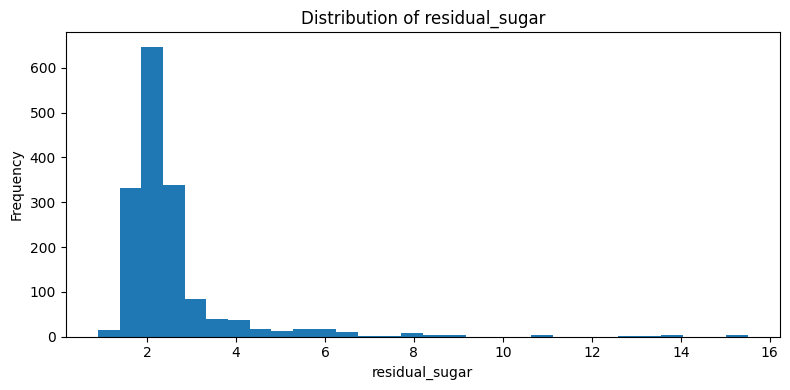

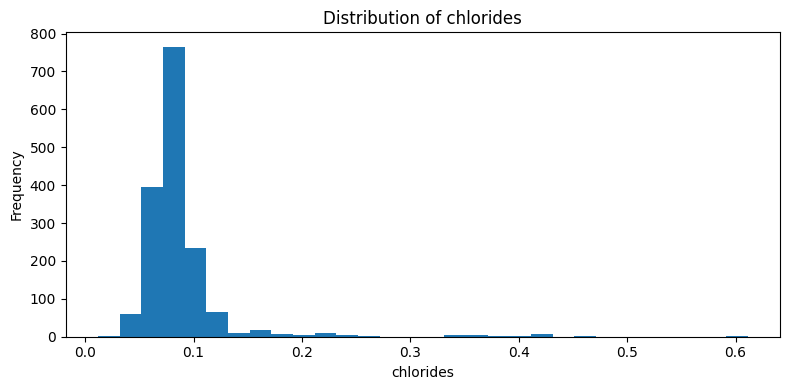

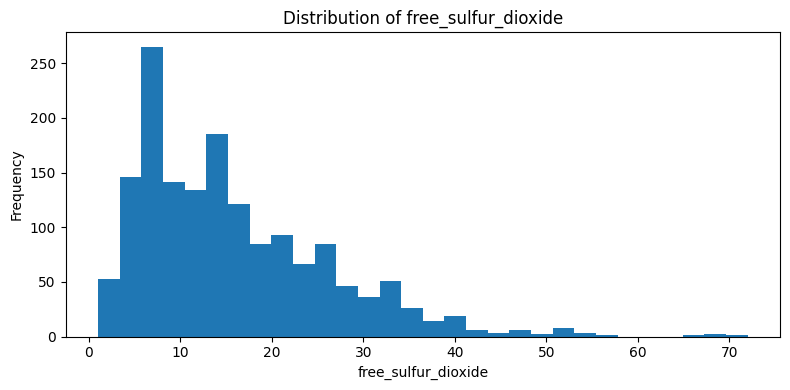

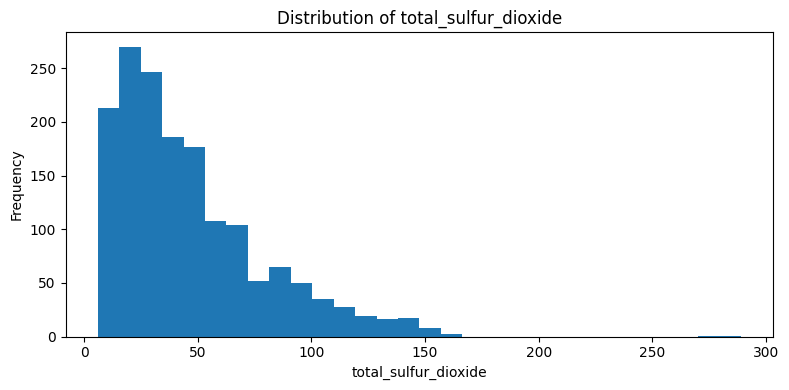

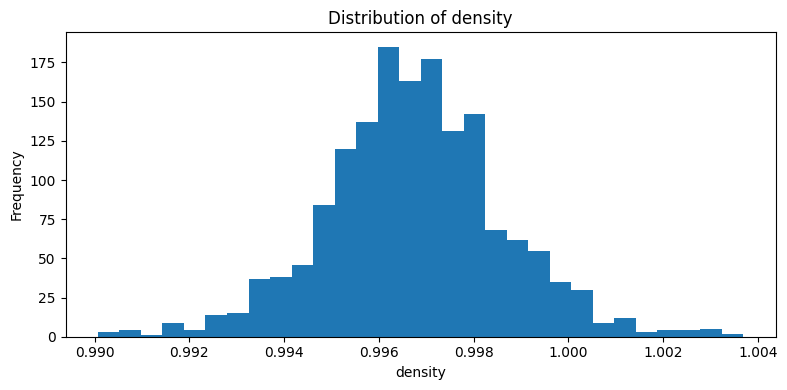

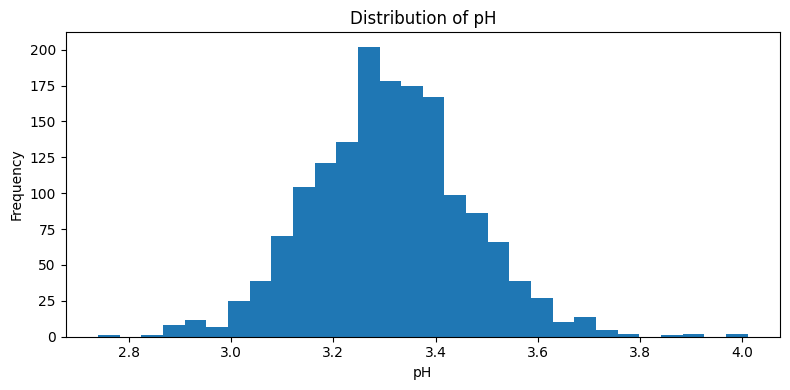

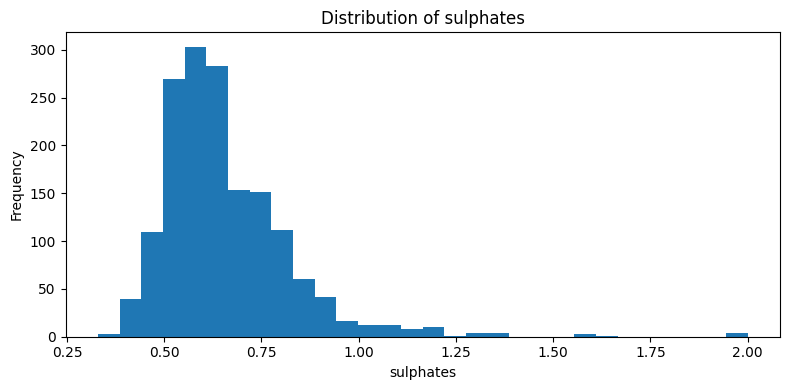

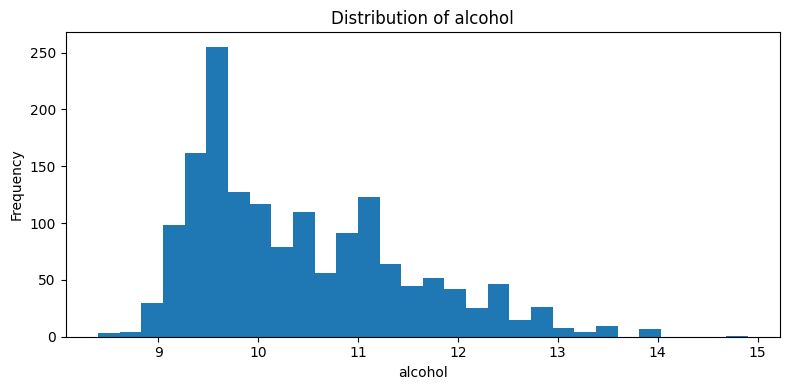

In [5]:
chemical_features = [
    "fixed_acidity",
    "volatile_acidity",
    "citric_acid",
    "residual_sugar",
    "chlorides",
    "free_sulfur_dioxide",
    "total_sulfur_dioxide",
    "density",
    "pH",
    "sulphates",
    "alcohol"
]
for feature in chemical_features:
    plt.figure(figsize=(8, 4))
    plt.hist(df[feature], bins=30)
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

## EDA – Chemical Feature Distributions

The distribution plots were examined to understand the spread and shape of the chemical features. The variables have different scales and distributions, which supports the need for feature standardisation before applying classification models such as Logistic Regression, SGD, and SVC.

## Class Imbalance Analysis

In [6]:
class_counts = df["quality_class"].value_counts()
class_percentages = df["quality_class"].value_counts(normalize=True) * 100
class_distribution = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_percentages.round(2)
})
class_distribution

,Count,Percentage
quality_class,,
Good,855,53.47
Bad,744,46.53


### Class Imbalance Observation

The binary target is reasonably balanced, with **53.47% Good wines** and **46.53% Bad wines**. The class proportions are sufficiently close that severe class imbalance is not present in the transformed target.

Therefore, SMOTE or undersampling is not required for this project. However, stratified train-test splitting will be used to preserve the class proportions in both the training and testing datasets.

In [7]:
from sklearn.model_selection import train_test_split

X = df[chemical_features]
y = df["quality_class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])
print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True).round(3))
print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training rows: 1279
Testing rows: 320

Training class distribution:
quality_class
Good    0.535
Bad     0.465
Name: proportion, dtype: float64

Testing class distribution:
quality_class
Good    0.534
Bad     0.466
Name: proportion, dtype: float64


## Feature Standardization

The chemical features have different numerical scales. To make the features comparable and improve the performance of scale-sensitive classification algorithms, `StandardScaler` will be applied.

The scaler will be fitted using only the training data and then used to transform both the training and testing data. This prevents information from the test set from influencing the training process.

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Training data shape: (1279, 11)
Testing data shape: (320, 11)


## Model 1 – Random Forest Classifier

In [9]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
rf_model.fit(X_train_scaled, y_train)
print("Random Forest model trained successfully.")

Random Forest model trained successfully.


## Model 2 – Stochastic Gradient Descent (SGD) Classifier


In [10]:
from sklearn.linear_model import SGDClassifier

sgd_model = SGDClassifier(
    random_state=42,
    max_iter=1000,
    tol=1e-3
)

sgd_model.fit(X_train_scaled, y_train)
print("SGD Classifier trained successfully.")

SGD Classifier trained successfully.


## Model 3 – Support Vector Classifier (SVC)

In [11]:
from sklearn.svm import SVC

svc_model = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

svc_model.fit(X_train_scaled, y_train)
print("SVC model trained successfully.")

SVC model trained successfully.


## Model Evaluation and Comparison


In [12]:
rf_pred = rf_model.predict(X_test_scaled)
sgd_pred = sgd_model.predict(X_test_scaled)
svc_pred = svc_model.predict(X_test_scaled)

print("Predictions generated successfully.")

Predictions generated successfully.


In [13]:
# Evaluate all three classifiers

models = {
    "Random Forest": (rf_model, rf_pred),
    "SGD Classifier": (sgd_model, sgd_pred),
    "SVC": (svc_model, svc_pred)
}
results = []
y_test_binary = (y_test == "Good").astype(int)

for model_name, (model, predictions) in models.items():
    precision = precision_score(
        y_test,
        predictions,
        pos_label="Good"
    )
    recall = recall_score(
        y_test,
        predictions,
        pos_label="Good"
    )
    f1 = f1_score(
        y_test,
        predictions,
        pos_label="Good"
    )
   
    if hasattr(model, "predict_proba"):
        scores = model.predict_proba(X_test_scaled)[:, 1]
    else:
        scores = model.decision_function(X_test_scaled)

    
    if hasattr(model, "classes_"):
        good_index = list(model.classes_).index("Good")
        if hasattr(model, "predict_proba"):
            scores = model.predict_proba(X_test_scaled)[:, good_index]

    roc_auc = roc_auc_score(y_test_binary, scores)
    results.append([
        model_name,
        precision,
        recall,
        f1,
        roc_auc
    ])
evaluation_results = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ]
)
evaluation_results.round(4)

,Model,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.8343,0.8246,0.8294,0.9065
1,SGD Classifier,0.6597,0.7368,0.6961,0.6797
2,SVC,0.8146,0.7193,0.7640,0.8365


## Model Comparison – Key Findings

The three classification models produced different results on the test dataset.

- **Random Forest** achieved a Precision of **0.8343**, Recall of **0.8246**, F1-Score of **0.8294**, and ROC-AUC of **0.9065**.
- **SGD Classifier** achieved a Precision of **0.6597**, Recall of **0.7368**, F1-Score of **0.6961**, and ROC-AUC of **0.6797**.
- **SVC** achieved a Precision of **0.8146**, Recall of **0.7193**, F1-Score of **0.7640**, and ROC-AUC of **0.8365**.

For this test set, Random Forest produced the strongest performance across the evaluated metrics.

## Confusion Matrix Analysis

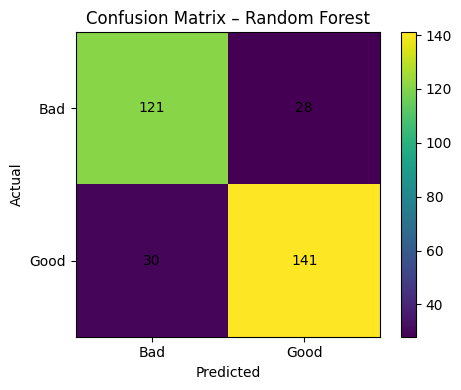

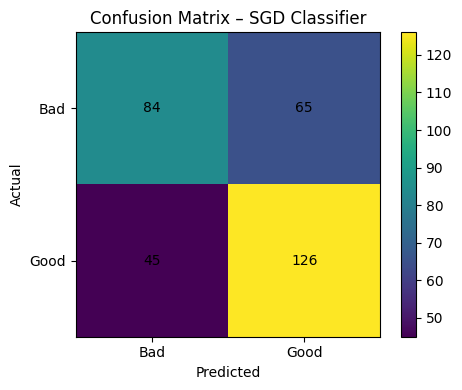

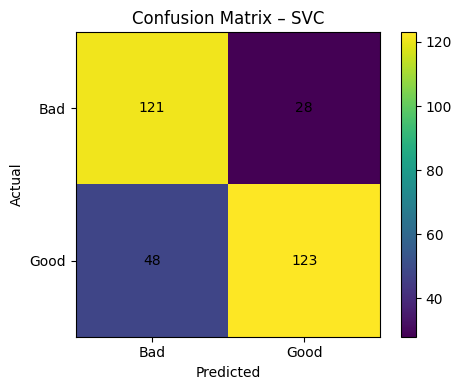

In [14]:
# Confusion matrices for all three models

model_predictions = {
    "Random Forest": rf_pred,
    "SGD Classifier": sgd_pred,
    "SVC": svc_pred
}

for model_name, predictions in model_predictions.items():
    cm = confusion_matrix(
        y_test,
        predictions,
        labels=["Bad", "Good"]
    )

    plt.figure(figsize=(5, 4))
    plt.imshow(cm)
    plt.colorbar()

    plt.xticks([0, 1], ["Bad", "Good"])
    plt.yticks([0, 1], ["Bad", "Good"])

    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix – {model_name}")
    plt.tight_layout()
    plt.show()

# Conclusion

The Wine Quality Prediction project was completed as a binary classification problem by converting the original quality scores into two classes: `Bad` for quality scores below 6 and `Good` for scores of 6 or above.

The project included dataset inspection, chemical feature distribution analysis, correlation analysis, class distribution analysis, stratified 80/20 train-test splitting, and feature standardization.

Three classification algorithms were trained and evaluated:

- Random Forest
- SGD Classifier
- Support Vector Classifier (SVC)

The models were evaluated using Precision, Recall, F1-Score, and ROC-AUC. Among the three models, Random Forest achieved the strongest test-set performance with a Precision of **0.8343**, Recall of **0.8246**, F1-Score of **0.8294**, and ROC-AUC of **0.9065**.

The confusion matrices were also examined to understand the classification errors made by each model.

The transformed target variable was reasonably balanced, so SMOTE or undersampling was not required. Stratified splitting was used to preserve the class proportions between the training and testing datasets.